In [354]:
from pyspark.sql import SparkSession
from pathlib import Path
from pyspark.sql import functions as F

CLEANED_DATA_DIR = Path("../data/cleaned")

spark = SparkSession.builder.appName("profiling").config("spark.sql.ansi.enabled", "false").config("spark.driver.memory", "16g").getOrCreate()
co2_df = spark.read.parquet(f"{CLEANED_DATA_DIR}/4c_eea_co2_emissions_from_passenger_cars-001.parquet")
eurostat_df = spark.read.csv('../data/cleaned/2c_eurostat_new_passenger_cars_by_type_of_motor_energy.csv', header=True)

Restrict temporal coverage of both datasets to the years 2014-2023.

In [355]:
# Unique values in the 'TIME_PERIOD' column
co2_df.select("TIME_PERIOD").distinct().orderBy("TIME_PERIOD").show()
eurostat_df.select("TIME_PERIOD").distinct().orderBy("TIME_PERIOD").show()

+-----------+
|TIME_PERIOD|
+-----------+
|       2013|
|       2014|
|       2015|
|       2016|
|       2017|
|       2018|
|       2019|
|       2020|
|       2021|
|       2022|
|       2023|
+-----------+

+-----------+
|TIME_PERIOD|
+-----------+
|       2014|
|       2015|
|       2016|
|       2017|
|       2018|
|       2019|
|       2020|
|       2021|
|       2022|
|       2023|
|       2024|
+-----------+



In [356]:
co2_df = co2_df.filter(F.col("TIME_PERIOD").between(2014, 2023))
eurostat_df = eurostat_df.filter(F.col("TIME_PERIOD").between(2014, 2023))

# Unique values in the 'TIME_PERIOD' column
co2_df.select("TIME_PERIOD").distinct().orderBy("TIME_PERIOD").show()
eurostat_df.select("TIME_PERIOD").distinct().orderBy("TIME_PERIOD").show()

+-----------+
|TIME_PERIOD|
+-----------+
|       2014|
|       2015|
|       2016|
|       2017|
|       2018|
|       2019|
|       2020|
|       2021|
|       2022|
|       2023|
+-----------+

+-----------+
|TIME_PERIOD|
+-----------+
|       2014|
|       2015|
|       2016|
|       2017|
|       2018|
|       2019|
|       2020|
|       2021|
|       2022|
|       2023|
+-----------+



Add in the EEA dataset for the 'Motor energy' column the values:
- 'Petrol' as the sum of the values 'Petrol (excluding hybrids)', Petrol hybrid;
- 'Diesel' as the sum of the values 'Diesel (excluding hybrids)', Diesel hybrid;

In [357]:
eea_detailed = (
    co2_df
    .groupBy(
        "geo",
        "Geopolitical entity (reporting)",
        "TIME_PERIOD",
        "Motor energy"
    )
    .agg(
        F.sum("registrations").alias("registrations")
    )
)

eea_detailed.show(20, truncate=False)

+---+-------------------------------+-----------+--------------------------+-------------+
|geo|Geopolitical entity (reporting)|TIME_PERIOD|Motor energy              |registrations|
+---+-------------------------------+-----------+--------------------------+-------------+
|FI |Finland                        |2015       |Diesel (excluding hybrids)|36603        |
|IT |Italy                          |2017       |Diesel (excluding hybrids)|1112208      |
|IT |Italy                          |2017       |Petrol hybrid             |3742         |
|IT |Italy                          |2020       |Petrol hybrid             |28388        |
|LT |Lithuania                      |2019       |Petrol hybrid             |59           |
|HU |Hungary                        |2021       |Diesel (excluding hybrids)|25289        |
|ES |Spain                          |2019       |Petrol hybrid             |7308         |
|RO |Romania                        |2022       |Petrol hybrid             |3688         |

- 'Petrol (all)' = 'Petrol (excluding hybrids)' + 'Petrol hybrid'
- 'Diesel (all)' = 'Diesel (excluding hybrids)' + 'Diesel hybrid'

In [358]:
eea_petrol = (
    eea_detailed
    .filter(
        F.col("Motor energy").isin(
            "Petrol (excluding hybrids)",
            "Petrol hybrid"
        )
    )
    .groupBy(
        "geo",
        "Geopolitical entity (reporting)",
        "TIME_PERIOD"
    )
    .agg(
        F.sum("registrations").alias("registrations")
    )
    .withColumn(
        "Motor energy",
        F.lit("Petrol (all)")
    )
)

eea_diesel = (
    eea_detailed
    .filter(
        F.col("Motor energy").isin(
            "Diesel (excluding hybrids)",
            "Diesel hybrid"
        )
    )
    .groupBy(
        "geo",
        "Geopolitical entity (reporting)",
        "TIME_PERIOD"
    )
    .agg(
        F.sum("registrations").alias("registrations")
    )
    .withColumn(
        "Motor energy",
        F.lit("Diesel (all)")
    )
)

eea_complete = (
    eea_detailed
    .unionByName(eea_petrol)
    .unionByName(eea_diesel)
    .orderBy("geo", "Geopolitical entity (reporting)", "TIME_PERIOD", "Motor energy")
)

eea_complete.show(20, truncate=False)

+---+-------------------------------+-----------+--------------------------+-------------+
|geo|Geopolitical entity (reporting)|TIME_PERIOD|Motor energy              |registrations|
+---+-------------------------------+-----------+--------------------------+-------------+
|AT |Austria                        |2014       |Alternative/Other         |795          |
|AT |Austria                        |2014       |Diesel (all)              |172207       |
|AT |Austria                        |2014       |Diesel (excluding hybrids)|172104       |
|AT |Austria                        |2014       |Diesel hybrid             |103          |
|AT |Austria                        |2014       |Electricity               |1281         |
|AT |Austria                        |2014       |Petrol (all)              |128581       |
|AT |Austria                        |2014       |Petrol (excluding hybrids)|128250       |
|AT |Austria                        |2014       |Petrol hybrid             |331          |

Check the distinct values of the 'Motor energy' column in both datasets to ensure consistency.

In [359]:
eea_complete.select("Motor energy").distinct().orderBy("Motor energy").show(20, truncate=False)

+--------------------------+
|Motor energy              |
+--------------------------+
|Alternative/Other         |
|Diesel (all)              |
|Diesel (excluding hybrids)|
|Diesel hybrid             |
|Electricity               |
|Petrol (all)              |
|Petrol (excluding hybrids)|
|Petrol hybrid             |
+--------------------------+



In [360]:
eurostat_df.select("Motor energy").distinct().orderBy("Motor energy").show(20, truncate=False)

+--------------------------+
|Motor energy              |
+--------------------------+
|Alternative/Other         |
|Diesel (all)              |
|Diesel (excluding hybrids)|
|Diesel hybrid             |
|Diesel plug-in hybrid     |
|Electricity               |
|Petrol (all)              |
|Petrol (excluding hybrids)|
|Petrol hybrid             |
|Petrol plug-in hybrid     |
|Total                     |
+--------------------------+



To ensure consistency between the datasets in aggregation, merge into 'hybrid' the 'plug-in hybrid' and 'hybrid' values for the Eurostat dataset too.

In [361]:
eurostat_df = (
    eurostat_df
    .withColumn(
        "Motor energy",
        F.when(
            F.col("Motor energy").isin("Petrol hybrid", "Petrol plug-in hybrid"),
            "Petrol hybrid"
        ).otherwise(F.col("Motor energy"))
    )
)

eurostat_df = (
    eurostat_df
    .withColumn(
        "Motor energy",
        F.when(
            F.col("Motor energy").isin("Diesel hybrid", "Diesel plug-in hybrid"),
            "Diesel hybrid"
        ).otherwise(F.col("Motor energy"))
    )
)

eurostat_df.select("Motor energy").distinct().orderBy("Motor energy").show(20, truncate=False)

+--------------------------+
|Motor energy              |
+--------------------------+
|Alternative/Other         |
|Diesel (all)              |
|Diesel (excluding hybrids)|
|Diesel hybrid             |
|Electricity               |
|Petrol (all)              |
|Petrol (excluding hybrids)|
|Petrol hybrid             |
|Total                     |
+--------------------------+



Prepare aggregated datasets for plotting.

In [362]:
eea = eea_complete.groupBy("geo", "Geopolitical entity (reporting)", "TIME_PERIOD", "Motor energy").agg(
    F.sum("registrations").alias("eea_registrations")
)

eurostat = eurostat_df.groupBy("geo", "Geopolitical entity (reporting)", "TIME_PERIOD", "Motor energy").agg(
    F.sum(F.col("OBS_VALUE").cast("double")).alias("eurostat_registrations")
)

comparison = (
    eea.join(eurostat, ["geo", "Geopolitical entity (reporting)", "TIME_PERIOD", "Motor energy"], "inner")
    .fillna(0, subset=["eea_registrations", "eurostat_registrations"])
)

comparison.show(20, truncate=False)

+---+-------------------------------+-----------+--------------------------+-----------------+----------------------+
|geo|Geopolitical entity (reporting)|TIME_PERIOD|Motor energy              |eea_registrations|eurostat_registrations|
+---+-------------------------------+-----------+--------------------------+-----------------+----------------------+
|FI |Finland                        |2015       |Diesel (excluding hybrids)|36603            |38800.0               |
|IT |Italy                          |2017       |Diesel (excluding hybrids)|1112208          |1130434.0             |
|LT |Lithuania                      |2019       |Petrol hybrid             |59               |3200.0                |
|HU |Hungary                        |2021       |Diesel (excluding hybrids)|25289            |19092.0               |
|ES |Spain                          |2019       |Petrol hybrid             |7308             |98116.0               |
|RO |Romania                        |2016       |Petrol 

### Heatmap years vs. motor energy with values as counts_difference between the EEA and the Eurostat dataset (in Thousands).

Show the difference between the two datasets in thousands:

$difference_{in\_thousands} = (eea_{registrations} - eurostat_{registrations}) \div 1000$

In [363]:
heatmap_df = (
    comparison.groupBy("Motor energy", "TIME_PERIOD")
    .agg(
        F.sum("eea_registrations").alias("eea_total"),
        F.sum("eurostat_registrations").alias("eurostat_total"),
    )
    .withColumn(
        "difference_in_thousands",
        F.when(F.col("eurostat_total") == 0, F.when(F.col("eea_total") == 0, 0).otherwise(100))
        .otherwise((F.col("eea_total") - F.col("eurostat_total")) / 1000)
    )
    .toPandas()
    .pivot(
        index="Motor energy", columns="TIME_PERIOD", values="difference_in_thousands"
    )
)

heatmap_df.rename(index={"Petrol": "Petrol (all)", "Diesel": "Diesel (all)"}, inplace=True)
heatmap_df = heatmap_df.drop("Alternative/Other", errors='ignore')

column_order = [
    "Petrol (all)",
    "Petrol (excluding hybrids)",
    "Petrol hybrid",
    "Diesel (all)",
    "Diesel (excluding hybrids)",
    "Diesel hybrid",
    "Electricity"
]
heatmap_df = heatmap_df.reindex(index=column_order)

display(heatmap_df)

TIME_PERIOD,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Motor energy,,,,,,,,,,
Petrol (all),31.961,24.871,-101.654,-84.179,-71.844,-106.176,-75.646,-36.408,-90.805,2.369
Petrol (excluding hybrids),48.264,103.772,-31.948,158.405,281.448,442.202,835.623,1474.534,1638.258,2206.979
Petrol hybrid,-65.409,-78.824,-129.000,-266.173,-357.636,-475.218,-751.648,-1511.507,-1729.063,-2204.610
Diesel (all),-21.441,48.958,-0.161,-55.634,-96.252,-87.186,-108.430,-111.784,-87.099,-112.801
Diesel (excluding hybrids),0.073,88.841,44.846,-51.484,-59.464,47.352,117.086,254.866,267.264,314.805
Diesel hybrid,-10.819,-15.476,-7.147,-4.877,-24.382,-116.011,-206.825,-367.093,-353.736,-426.579
Electricity,0.102,0.197,0.470,0.089,-0.407,-7.370,-0.401,-2.899,-17.548,5.279


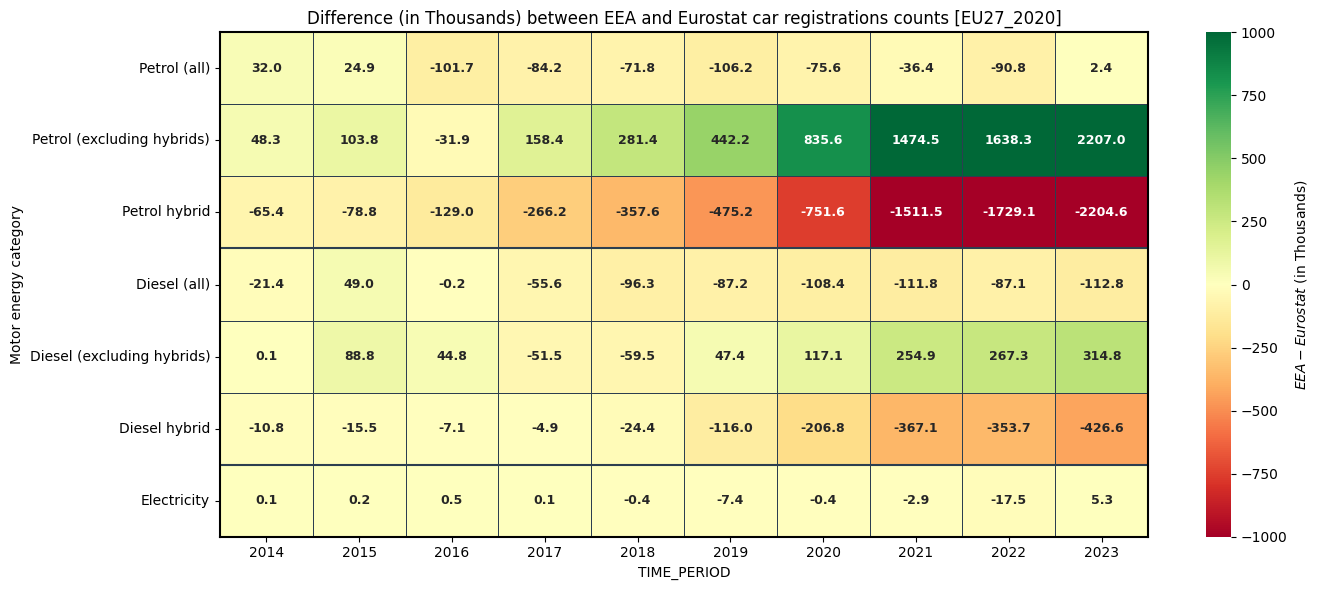

In [364]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
annot_labels = heatmap_df.map(lambda x: f"{x:.1f}")
ax = sns.heatmap(
    heatmap_df,
    annot=annot_labels,
    fmt="",
    annot_kws={"weight": "bold", "size": 9},
    cmap="RdYlGn",
    vmin=-1000,
    vmax=1000,
    center=0,
    linewidths=0.5,
    linecolor="#2c3e50",
    cbar_kws={"label": "$EEA - Eurostat$ (in Thousands)"}
)

# Heatmap border
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.5)

thick_lines = [3, 6]
for row in thick_lines:
    ax.axhline(
        y=row, 
        color="#2c3e50",
        linewidth=1.5
    )

plt.xlabel("TIME_PERIOD")
plt.ylabel("Motor energy category")
plt.title("Difference (in Thousands) between EEA and Eurostat car registrations counts [EU27_2020]")

plt.tight_layout()
plt.savefig("img/validation_heatmap_difference_in_thousands.png", dpi=300)
plt.show()

### Heatmap years vs. motor energy with values as percentage_difference between the EEA and the Eurostat dataset.

Prepare the data for the heatmap by creating the 'eea_registrations' and 'eurostat_registrations' columns, which represent the number of registrations for each 'geo', 'TIME_PERIOD', and 'Motor energy' combination. Then calculate the percentage difference between the two datasets using the formula:

$percentage\_difference = ((eea_{registrations} - eurostat_{registrations}) / eurostat_{registrations}) * 100$

In [365]:
heatmap_df = (
    comparison.groupBy("Motor energy", "TIME_PERIOD")
    .agg(
        F.sum("eea_registrations").alias("eea_total"),
        F.sum("eurostat_registrations").alias("eurostat_total"),
    )
    .withColumn(
        "percentage_difference",
        F.when(F.col("eurostat_total") == 0, F.when(F.col("eea_total") == 0, 0).otherwise(100))
        .otherwise(((F.col("eea_total") - F.col("eurostat_total")) / F.col("eurostat_total")) * 100)
    )
    .toPandas()
    .pivot(
        index="Motor energy", columns="TIME_PERIOD", values="percentage_difference"
    )
)

heatmap_df.rename(index={"Petrol": "Petrol (all)", "Diesel": "Diesel (all)"}, inplace=True)

display(heatmap_df)

TIME_PERIOD,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Motor energy,,,,,,,,,,
Alternative/Other,-57.849016,-60.163187,-37.603982,-57.999030,-53.017777,-67.891253,-79.831340,-81.968553,-82.000690,-83.976006
Diesel (all),-0.416674,0.893016,-0.002853,-1.005401,-2.048812,-2.064427,-3.470189,-4.705100,-4.515407,-5.821539
Diesel (excluding hybrids),0.002077,2.402502,1.144888,-0.943781,-1.289810,1.161422,4.093259,13.035117,17.428776,21.268036
Diesel hybrid,-90.015808,-65.324385,-76.413985,-53.190097,-89.102470,-91.017574,-84.856852,-87.281732,-89.638290,-93.457233
Electricity,0.328164,0.422538,0.878505,0.106284,-0.302902,-2.949250,-0.074501,-0.328363,-1.557109,0.342503
Petrol (all),0.773216,0.527947,-1.872472,-1.307815,-0.971703,-1.336465,-1.224076,-0.582265,-1.530177,0.035200
Petrol (excluding hybrids),2.158131,3.941783,-1.000098,2.740518,4.262930,6.082495,17.475511,37.463535,48.412337,59.069061
Petrol hybrid,-69.843355,-57.282386,-74.930297,-77.012080,-78.258187,-79.881326,-62.111713,-65.238110,-67.798097,-73.638843


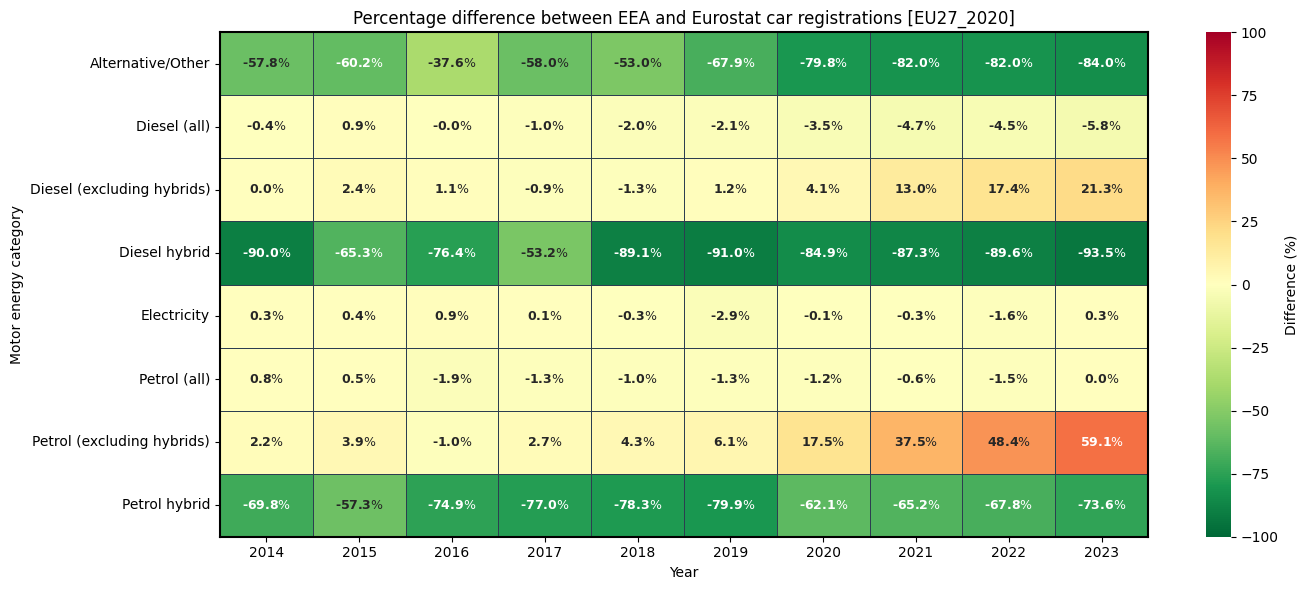

In [366]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
annot_labels = heatmap_df.map(lambda x: f"{x:.1f}$\%$")
ax = sns.heatmap(
    heatmap_df,
    annot=annot_labels,
    fmt="",
    annot_kws={"weight": "bold", "size": 9},
    cmap="RdYlGn_r",
    vmin=-100,
    vmax=100,
    center=0,
    linewidths=0.5,
    linecolor="#2c3e50",
    cbar_kws={"label": "Difference (%)"}
)

# Heatmap border
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.5)

plt.xlabel("Year")
plt.ylabel("Motor energy category")
plt.title("Percentage difference between EEA and Eurostat car registrations [EU27_2020]")

plt.tight_layout()
plt.show()

> Both datasets agree on the overall fuel family, but not necessarily on the hybrid classification!

NOTE: The calculation yields extreme values for specific hybrid/non-hybrid categories, while standard categories (Petrol, Diesel, Electricity) remain stable near 0%. This confirms that both datasets agree on the overall fuel family volume, but differ heavily on how hybrids are classified. The massive positive gap in "excluding hybrids" perfectly mirrors the negative gap in "hybrids", indicating a pure taxonomy misalignment rather than a data collection error.

### Heatmap years vs. motor energy with values as 'percentage_difference (difference_in_thousands)' between the EEA and the Eurostat dataset.

### Heatmap geo vs. motor energy with values as percentage_difference between the EEA and the Eurostat dataset.

In [367]:
heatmap_df = (
    comparison.groupBy("Geopolitical entity (reporting)", "TIME_PERIOD")
    .agg(
        F.sum("eea_registrations").alias("eea_total"),
        F.sum("eurostat_registrations").alias("eurostat_total"),
    )
    .withColumn(
        "percentage_difference",
        F.when(F.col("eurostat_total") == 0, F.when(F.col("eea_total") == 0, 0).otherwise(100))
        .otherwise(((F.col("eea_total") - F.col("eurostat_total")) / F.col("eurostat_total")) * 100)
    )
    .toPandas()
    .pivot(
        index="Geopolitical entity (reporting)", columns="TIME_PERIOD", values="percentage_difference"
    )
)

display(heatmap_df)

TIME_PERIOD,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Geopolitical entity (reporting),,,,,,,,,,
Austria,-0.491893,-0.491160,-0.760155,-0.944187,-1.264997,-1.828985,-4.337059,-7.346864,-8.266915,-10.228936
Belgium,-0.715178,-0.831452,-1.347445,-1.444692,-2.454766,-3.106529,-4.077788,-5.590323,-7.556601,-11.549421
Bulgaria,100.000000,-13.293051,4.393673,12.121212,79.633867,-49.937682,3.788732,-6.698842,-6.325259,-8.110524
Croatia,-83.470649,-88.805268,-79.954663,-91.472114,-88.706323,-88.835678,-4.513362,24.080747,11.233938,25.413760
Cyprus,-3.264813,-8.964203,-6.845358,-2.740458,-2.865089,-4.748648,-4.390172,-1.875412,-2.854798,-2.499473
Czechia,100.000000,1234.294872,538.095238,911.436170,304.240766,266.195373,-4.483153,-3.588173,2.178576,-0.383128
Denmark,-0.693184,-0.383554,-0.906868,-1.035115,-2.293626,-2.515734,-5.312118,-9.897262,-62.247044,-18.641673
Estonia,-1.661303,-0.410653,-0.725456,0.269310,-0.015231,-2.015512,-6.389251,-3.920658,-4.460334,-4.722440
Finland,-3.405187,-3.139617,-3.305462,-3.852868,-4.568690,-6.372480,-6.158083,-9.066863,-12.101739,-19.735684


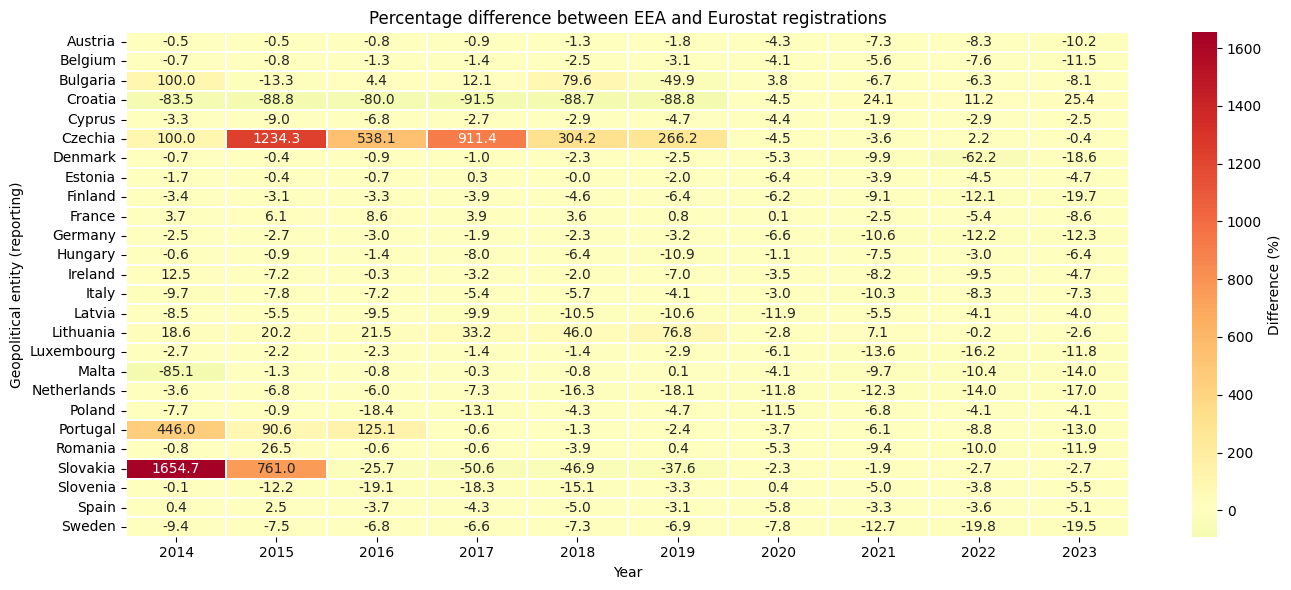

In [368]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    center=0,
    linewidths=0.3,
    cbar_kws={
        "label": "Difference (%)"
    }
)

plt.xlabel("Year")
plt.ylabel("Geopolitical entity (reporting)")

plt.title("Percentage difference between EEA and Eurostat registrations")

plt.tight_layout()
plt.show()